In [1]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression
import os
import streamlit as st
import plotly.express as px
import seaborn as sns


glu = pd.read_sas('GLU_L.xpt', format='xport')
demo = pd.read_sas('DEMO_L.xpt' ,format='xport')
paq = pd.read_sas('PAQ_L.xpt', format = 'xport')
ins = pd.read_sas('INS_L.xpt', format = 'xport')
crp = pd.read_sas('HSCRP_L.xpt', format = 'xport')
hba1 = pd.read_sas('GHB_L.xpt', format = 'xport' )



# View the first few rows
##print(glu.head())
##print("\n")
##print("-------------------")
##print(demo.head())
glu.set_index('SEQN', inplace = True)
demo.set_index('SEQN', inplace = True)
paq.set_index('SEQN', inplace = True)
ins.set_index('SEQN', inplace = True)
crp.set_index('SEQN', inplace = True)
hba1.set_index('SEQN', inplace = True)

## Dropping weight column since gluc dataset has it
ins.drop(columns=['WTSAF2YR'], inplace=True)
hba1.drop(columns = ['WTPH2YR'], inplace=True)
print('glu')
print(glu.info())


print('demo')
print(demo.info())
print('paq')
print(paq.info())
print('ins')
print(ins.info())
print('crp')
print(crp.info())
print('hba1')
print(hba1.info())
merged1 = pd.merge(glu, demo, on="SEQN", how="inner")

merged2 = pd.merge(paq, merged1, on="SEQN", how="inner")
merged3 = pd.merge(ins, merged2, on="SEQN", how="inner")
merged4 = pd.merge(crp, merged3, on="SEQN", how="inner")
dfs = [merged4, hba1]
df_merged = pd.concat(dfs, axis=1, join="inner").reset_index()
merged4 = df_merged.copy()
print('-------------')
print('df_merged')
print(df_merged.head())
print('--------------')
print('merged4')
print(merged4.head())









glu
<class 'pandas.core.frame.DataFrame'>
Float64Index: 3996 entries, 130378.0 to 142309.0
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   WTSAF2YR  3996 non-null   float64
 1   LBXGLU    3672 non-null   float64
 2   LBDGLUSI  3672 non-null   float64
dtypes: float64(3)
memory usage: 124.9 KB
None
demo
<class 'pandas.core.frame.DataFrame'>
Float64Index: 11933 entries, 130378.0 to 142310.0
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SDDSRVYR  11933 non-null  float64
 1   RIDSTATR  11933 non-null  float64
 2   RIAGENDR  11933 non-null  float64
 3   RIDAGEYR  11933 non-null  float64
 4   RIDAGEMN  377 non-null    float64
 5   RIDRETH1  11933 non-null  float64
 6   RIDRETH3  11933 non-null  float64
 7   RIDEXMON  8860 non-null   float64
 8   RIDEXAGM  2787 non-null   float64
 9   DMQMILIZ  8301 non-null   float64
 10  DMDBORN4  11914 non-null  float64
 1

In [2]:
print(merged4.head())

       SEQN       WTPH2YR  LBXHSCRP      LBDHRPLC  LBXIN  LBDINSI  \
0  130378.0  56042.129410      1.78  5.397605e-79  15.53    93.18   
1  130379.0  37435.705647      2.03  5.397605e-79  19.91   119.46   
2  130380.0  85328.844519      5.62  5.397605e-79  16.33    97.98   
3  130386.0  44526.214135      1.05  5.397605e-79  11.38    68.28   
4  130394.0  52478.876664      0.92  5.397605e-79   7.20    43.20   

        LBDINLC  PAD790Q PAD790U  PAD800  ...  DMDHRAGZ DMDHREDZ  DMDHRMAZ  \
0  5.397605e-79      3.0    b'W'    45.0  ...       NaN      NaN       NaN   
1  5.397605e-79      4.0    b'W'    45.0  ...       NaN      NaN       NaN   
2  5.397605e-79      1.0    b'W'    20.0  ...       NaN      NaN       NaN   
3  5.397605e-79      1.0    b'W'    30.0  ...       NaN      NaN       NaN   
4  5.397605e-79      7.0    b'W'    45.0  ...       NaN      NaN       NaN   

   DMDHSEDZ      WTINT2YR      WTMEC2YR  SDMVSTRA  SDMVPSU  INDFMPIR  LBXGH  
0       NaN  50055.450807  54374.46389

In [24]:
glu_weight = 'WTSAF2YR'
crp_weight = 'WTPH2YR'
hba1_weight = 'WTPH2YR'
demo_weight = 'WTINT2YR'


In [25]:
# this dataset will be used to predict age based on insulin, glucose and crp
df_clean = merged4.dropna(how = 'all').copy()
# = merged4.dropna(subset=[glu_weight, crp_weight, 'LBXGLU', 'RIAGENDR', 'RIDAGEYR', 'LBXIN', 'LBXHSCRP', 'LBXGH' ]).copy()
print(df_clean)

          SEQN       WTPH2YR  LBXHSCRP      LBDHRPLC  LBXIN  LBDINSI  \
0     130378.0  5.604213e+04      1.78  5.397605e-79  15.53    93.18   
1     130379.0  3.743571e+04      2.03  5.397605e-79  19.91   119.46   
2     130380.0  8.532884e+04      5.62  5.397605e-79  16.33    97.98   
3     130386.0  4.452621e+04      1.05  5.397605e-79  11.38    68.28   
4     130394.0  5.247888e+04      0.92  5.397605e-79   7.20    43.20   
...        ...           ...       ...           ...    ...      ...   
3557  142301.0  1.778209e+04      1.11  5.397605e-79   5.62    33.72   
3558  142303.0  4.777860e+04      2.15  5.397605e-79  17.09   102.54   
3559  142305.0  4.971093e+04      2.50  5.397605e-79  24.86   149.16   
3560  142308.0  5.397605e-79       NaN           NaN    NaN      NaN   
3561  142309.0  4.628442e+04      0.53  5.397605e-79   6.22    37.32   

           LBDINLC       PAD790Q PAD790U  PAD800  ...  DMDHRAGZ DMDHREDZ  \
0     5.397605e-79  3.000000e+00    b'W'    45.0  ...      

In [84]:
df_clean.dropna(how = 'all', inplace = True)
df_clean['weigthed_glu'] = df_clean[glu_weight] / 1000000 * df_clean['LBXGLU'] / df_clean[glu_weight].sum()/1000000
df_clean['weighted_ins'] = df_clean[glu_weight] / 1000000 * df_clean['LBXIN'] / df_clean[glu_weight].sum()/1000000
df_clean['weighted_crp'] = df_clean[crp_weight] / 1000000 * df_clean['LBXHSCRP'] / df_clean[crp_weight].sum()/1000000
df_clean['weighted_hba1'] = df_clean[hba1_weight] / 1000000 * df_clean['LBXGH'] / df_clean[hba1_weight].sum() / 1000000
df_clean['weighted_age'] = df_clean[demo_weight] / 1000000 * df_clean['RIDAGEYR'] / df_clean[demo_weight].sum() / 1000000
##df_clean['weighted_gender'] = df_clean[demo_weight] / 1000000 * df_clean['RIAGENDR'] / df_clean[demo_weight].sum() / 1000000
##df_clean['weighted_race'] = df_clean[demo_weight] / 1000000 * df_clean['RIDRETH3'] / df_clean[demo_weight].sum() / 1000000
## df_clean = df_clean.drop(['weighted_race'], axis=1)
#df_clean = df_clean.drop(['weighted_gender'], axis =1)

In [77]:
print(df_clean.head())

       SEQN       WTPH2YR  LBXHSCRP      LBDHRPLC  LBXIN  LBDINSI  \
0  130378.0  56042.129410      1.78  5.397605e-79  15.53    93.18   
1  130379.0  37435.705647      2.03  5.397605e-79  19.91   119.46   
2  130380.0  85328.844519      5.62  5.397605e-79  16.33    97.98   
3  130386.0  44526.214135      1.05  5.397605e-79  11.38    68.28   
4  130394.0  52478.876664      0.92  5.397605e-79   7.20    43.20   

        LBDINLC  PAD790Q PAD790U  PAD800  ...      WTMEC2YR SDMVSTRA  SDMVPSU  \
0  5.397605e-79      3.0    b'W'    45.0  ...  54374.463898    173.0      2.0   
1  5.397605e-79      4.0    b'W'    45.0  ...  34084.721548    173.0      2.0   
2  5.397605e-79      1.0    b'W'    20.0  ...  81196.277992    174.0      1.0   
3  5.397605e-79      1.0    b'W'    30.0  ...  39988.452940    179.0      1.0   
4  5.397605e-79      7.0    b'W'    45.0  ...  51305.024430    174.0      2.0   

   INDFMPIR  LBXGH  weigthed_glu  weighted_ins  weighted_crp  weighted_hba1  \
0      5.00    5.6 

In [78]:
                                          
#df_younger_than_35 = df_clean[df_clean['RIDAGEYR'] <= 40]





## select only needed variables (hba1c, crp, glucose, insuline, age, gender, race)
##df_for_bio_age_pred =  df_clean[['weighted_hba1', 'weighted_crp', 'weighted_ins', 'weigthed_glu', 'weighted_age', 'weighted_gender', 'weighted_race' ]].copy()
## select only needed variables (hba1c, crp, glucose, insuline, age)
df_for_bio_age_pred =  df_clean[['weighted_hba1', 'weighted_crp', 'weighted_ins', 'weigthed_glu', 'weighted_age' ]].copy()
df_for_bio_age_pred = df_for_bio_age_pred.dropna(subset = ['weighted_hba1', 'weighted_crp', 'weighted_ins', 'weigthed_glu', 'weighted_age' ])

print("-----df_for_bio_age_pred-----")
print(df_for_bio_age_pred.head())
print(df_for_bio_age_pred.info())


-----df_for_bio_age_pred-----
   weighted_hba1  weighted_crp  weighted_ins  weigthed_glu  weighted_age
0   2.197483e-15  6.984856e-16  7.325313e-15  5.330073e-14  1.963880e-14
1   1.467901e-15  5.321143e-16  4.223323e-98  2.099995e-97  1.751640e-14
2   3.704336e-15  3.357802e-15  9.311247e-15  8.895007e-14  3.214238e-14
3   1.590043e-15  3.273617e-16  3.694045e-15  3.246085e-14  9.615453e-15
4   1.763797e-15  3.380611e-16  2.841424e-15  3.472852e-14  1.950937e-14
<class 'pandas.core.frame.DataFrame'>
Int64Index: 3156 entries, 0 to 3561
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weighted_hba1  3156 non-null   float64
 1   weighted_crp   3156 non-null   float64
 2   weighted_ins   3156 non-null   float64
 3   weigthed_glu   3156 non-null   float64
 4   weighted_age   3156 non-null   float64
dtypes: float64(5)
memory usage: 147.9 KB
None


In [79]:
## Viewing correlation

In [80]:
import math
## This line is needed because matplotlib will not work with plt.show() since it defaulted to Agg,
## which is a non-interactive, file-writing backend designed to generate static files (like saving a PNG) rather than rendering a GUI 
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


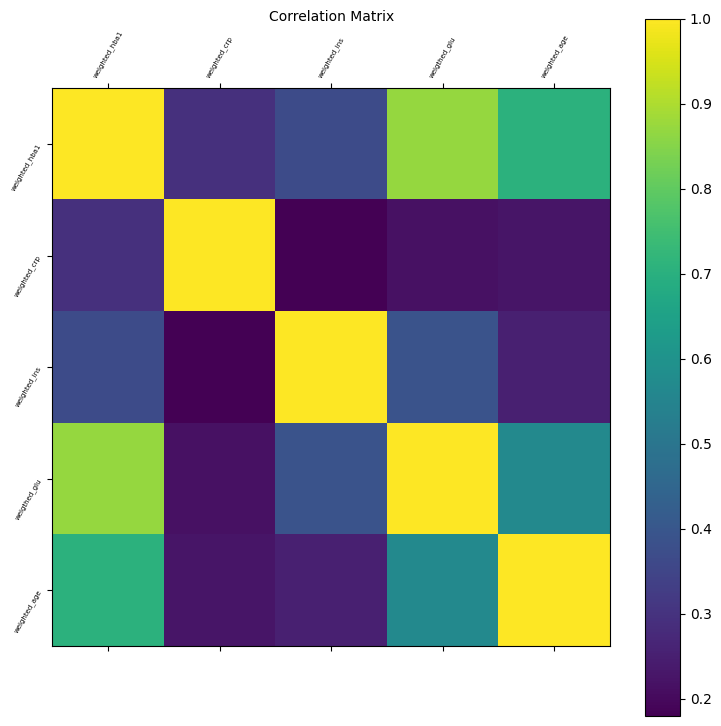

In [81]:
f = plt.figure(figsize=(9, 9))
plt.matshow(df_for_bio_age_pred.corr(), fignum=f.number)
plt.xticks(range(df_for_bio_age_pred.select_dtypes(['number']).shape[1]),
           df_for_bio_age_pred.\
           select_dtypes(['number']).columns, \
           fontsize=5, rotation=60)
plt.yticks(range(df_for_bio_age_pred.select_dtypes(['number']).shape[1]),
           df_for_bio_age_pred.\
           select_dtypes(['number']).columns, fontsize=5, rotation=60)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=10)
plt.title('Correlation Matrix', fontsize=10)
plt.show()

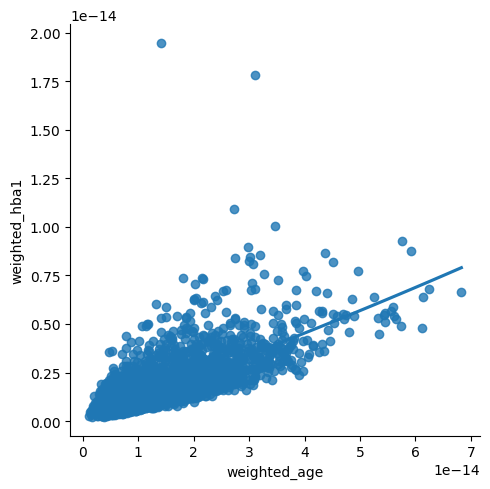

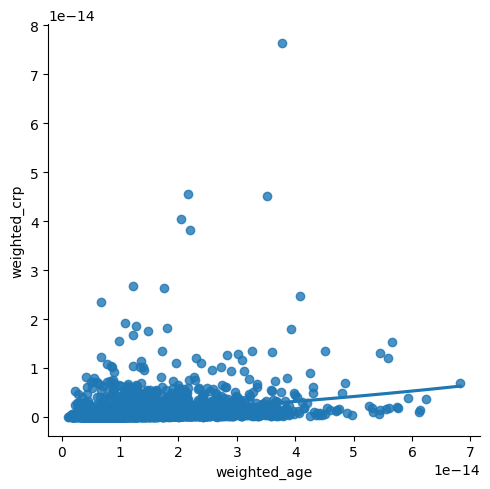

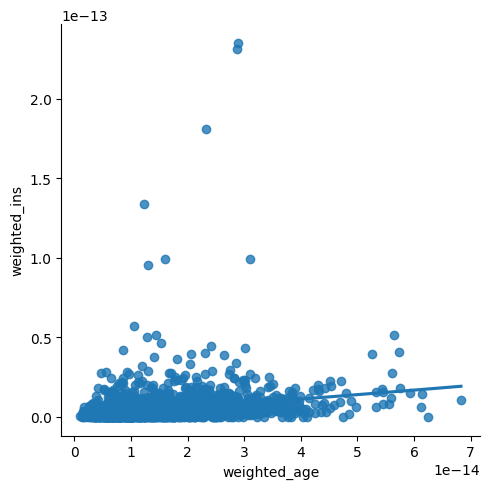

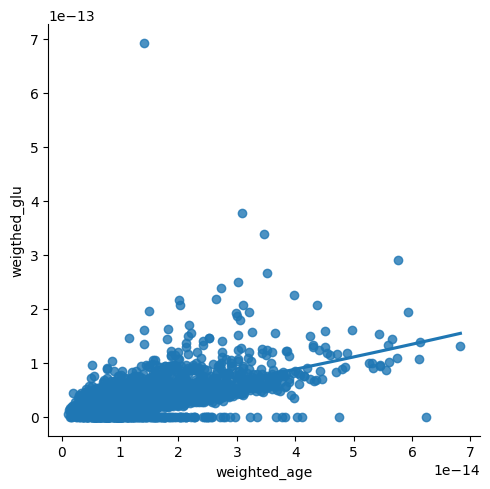

In [82]:
## Checking the relationship between age and each variable
## With hba1c
sns.lmplot(x ="weighted_age", y ="weighted_hba1", data = df_for_bio_age_pred , order = 2, ci = None)
plt.show()
## With crp
sns.lmplot(x ="weighted_age", y ="weighted_crp", data = df_for_bio_age_pred , order = 2, ci = None)
## With insulin
sns.lmplot(x ="weighted_age", y ="weighted_ins", data = df_for_bio_age_pred , order = 2, ci = None)
## With fasting glucose
sns.lmplot(x ="weighted_age", y ="weigthed_glu", data = df_for_bio_age_pred , order = 2, ci = None)


In [83]:
target_name = 'bio_age'
target_var =  df_for_bio_age_pred['weighted_age']

In [15]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    df_for_bio_age_pred, target_var, random_state=42
)
_ = model.fit(data_train, target_train)



pred = model.predict(data_test)[:]

st.write(model.score(data_test, target_test))


filename = 'trained_model_regression.joblib'
with open(filename, 'wb') as file:
    joblib.dump(model, file)

NameError: name 'model' is not defined